In [45]:
## Working with flow data
import numpy as np
import FlowCal
import matplotlib.pyplot as plt
import os
import matplotlib.gridspec as gridspec
path = "./"

files = os.listdir(path)

In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_li, threshold_yen, threshold_otsu, threshold_triangle
from math import sqrt
from skimage.feature import blob_dog, blob_log, blob_doh
import pickle as pkl
import sys
from datetime import date
import os
import psutil
from skimage.exposure import rescale_intensity
import cv2
import pandas as pd
from copy import deepcopy
from tqdm import tqdm

process = psutil.Process(os.getpid())

# Set utils directory and append to sys.path
utilsDir = '/mnt/disks/external/juj2102/cyTOFcmap/'
sys.path.append(utilsDir)
print(utilsDir)
opdir = '/mnt/disks/external/juj2102/cyTOFcmap/checkoutput/'

# Built-in Utilities
import re
import multiprocessing
from itertools import repeat
from tqdm import trange

# Data Wrangling and Plotting
from matplotlib.backends.backend_pdf import PdfPages

# Import blackbox module
import blackbox as bb

/mnt/disks/external/juj2102/cyTOFcmap/


In [28]:
class barcodeReadout:
    def __init__(self, intensity_table, codebook, low_param = 130, upper_param = 250, codebook_order = None, splot_file = None, log = True, test_subset=False, kernel_size = 20):

        # Get intensity table and provide some boundaries around the thresholds
        self.log = log
        #intensity_table[intensity_table < 100] = 100
        #self.intensity_table = self.add_random_n_places(intensity_table.values, 2)
        self.intensity_table = intensity_table.values
        self.readout_names = intensity_table.columns.to_numpy()
        self.entry_ids = intensity_table.index

        if self.log:
            self.intensity_table = np.emath.logn(10, self.intensity_table+1)
            self.intensity_table.astype('float32')
        
        self.bounds = []
        for readout_counter in range(self.intensity_table.shape[1]):

            if log:
                lb = np.emath.logn(10, low_param)
                ub = np.emath.logn(10, upper_param)
            else:
                lb = low_param
                ub = upper_param
            bounds = [lb, ub]
            self.bounds.append(bounds)
            
        self.codebook = codebook
        if codebook_order is not None:
            self.codebook = self.codebook[codebook_order]
        self.codebook = self.codebook.transpose()

        # Check that number of codebook entries matches the number of readout images
        if intensity_table.shape[1] != self.codebook.shape[0]:
            raise ValueError("Number of readout values doesn't match the number of codebook entries")
        
        self.test_subset = test_subset
        self.kernel_size = kernel_size

        # Attributes that will be assigned as the guide identification is completed
        self.binary_table = None
        self.optim_threshs = None
        self.distr_params = None
        self.overlap_assignment = None
        self.max_logprobs = None
        self.entropy = None
        self.prob_ratio = None
        self.prob_assignment = None
        
    def add_random_n_places(self, a, n):
        # Generate a float version
        out = a.astype(float)
    
        # Generate unique flattened indices along the size of a
        idx = np.random.choice(a.size, n, replace=False)
    
        # Assign into those places ramdom numbers in [-1,1)
        out.flat[idx] += np.random.uniform(low=-1, high=1, size=n)
        return out    
    def get_intensity_table(self):
        return self.intensity_table

    def overlap_optimization(self, batch_size = 50):
        # use blackbox optimizer to find optimal thresholds
        results = bb.minimize(f=score_fun, 
                              domain=self.bounds, 
                              budget = self.intensity_table.shape[1]*10*2, # 20 iterations per channel seems okay
                              batch=batch_size)
        self.optim_threshs = results['best_x']
        self.binary_table = np.zeros(self.intensity_table.shape, dtype=bool)
        for i in range(self.intensity_table.shape[1]):
            self.binary_table[:,i] = self.intensity_table[:,i]>self.optim_threshs[i]

        self.__assign_identities()
        return

    def probabilistic_assignment(self, ratio = 5):
        self.__calculate_intens_distrs()
        selector = np.array(self.codebook)
        mean_mtx = np.zeros(selector.shape, dtype = 'float32')
        sd_mtx = np.zeros(selector.shape, dtype = 'float32')
        
        for i in range(selector.shape[1]):
            mean_mtx[selector[:,i],i] = self.distr_params[selector[:,i],1,0]
            mean_mtx[~selector[:,i],i] = self.distr_params[~selector[:,i],0,0]
            sd_mtx[selector[:,i],i] = self.distr_params[selector[:,i],1,1]
            sd_mtx[~selector[:,i],i] = self.distr_params[~selector[:,i],0,1]
        
        # log probability for each cell - this is the gaussian log prob vectorized out for performance resasons
        z_table = (self.intensity_table[:,:,np.newaxis] - mean_mtx[np.newaxis,:,:])/sd_mtx[np.newaxis,:,:]
        logc = np.log(np.sqrt(2*np.pi))
        logpdf_table = -z_table**2/2.0 - logc
        
        # Assign to guide id
        guide_logprobs = np.sum(logpdf_table, axis = 1)
        columns = np.array(self.codebook.columns)
        guide_ids = columns[np.argmax(guide_logprobs, axis = 1)]
        self.max_logprobs = np.max(guide_logprobs,axis=1)
        self.entropy = np.apply_along_axis(self.__logp_entropy, 1, guide_logprobs)
        self.prob_ratio = np.apply_along_axis(self.__calc_pratio, 1, guide_logprobs)

        log_probThresh = np.percentile(self.max_logprobs[self.overlap_assignment!='Unassigned'], 5)
        likelyCells = (self.prob_ratio>ratio) * (self.max_logprobs>log_probThresh)
        guide_ids[~likelyCells] = 'Unassigned'
        self.prob_assignment = guide_ids.   astype('U')
        return

    def get_assignment(self, overlap_assign = False):
        if self.overlap_assignment is None:
            raise ValueError('No Guide identification performed yet')

        if overlap_assign:
            cell_assignments = self.overlap_assignment
        elif (not overlap_assign) and (self.prob_assignment is None):
            print('Probabilistic Assignment not performed yet. Returning overlap assignment')
            cell_assignments = self.overlap_assignment
        else:
            cell_assignments = self.prob_assignment
            
        return self.entry_ids, cell_assignments
        
        
    def plot_results(self, plotFile = None):
        if plotFile is not None:
            pdf = PdfPages(plotFile)
        
        # Make three plots - one for the tophat images & selected thresholds, the histogram of the number of positive cells, and the pos/neg distribution for each readout
        readout_count = self.intensity_table.shape[1]
        num_rows = int(sqrt(readout_count))
        num_cols = int(np.ceil(readout_count/num_rows))

        fig1, ax = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 5*num_rows))
        axarr = ax.ravel()
        for i in range(readout_count):
            values = self.intensity_table[:,i]
            values = values[~np.isnan(values)]
            bins = np.linspace(np.percentile(values, 1), np.percentile(values, 99), 100)
            if self.log:
                xlab = 'log(intensity)'
            else:
                xlab = 'intensity'
            axarr[i].hist(values, bins = bins)
            axarr[i].set_title(self.readout_names[i])
            axarr[i].set_xlabel(xlab)

        for i, bound in enumerate(self.bounds):
            axarr[i].axvline(bound[0], color = 'r', linestyle = '--')
            axarr[i].axvline(bound[1], color = 'r', linestyle = '--')
            if self.optim_threshs is not None:
                axarr[i].axvline(self.optim_threshs[i], color = 'b', linestyle = '--')
        if plotFile is not None:
            pdf.savefig(fig1)
            

        if self.binary_table is not None:
            num_pos = np.sum(self.binary_table, axis = 1)
            optim_Overlaps = np.where(num_pos==4)
            breaks = np.linspace(0, np.max(num_pos), int(np.max(num_pos))+1)
            fig2, ax = plt.subplots(1, 1, figsize=(10, 10))
            ax.hist(num_pos, breaks, width = 0.9, align = 'mid')
            ax.set_xticks(breaks+0.5)
            ax.set_xticklabels(breaks.astype(int))
            ax.set_title(f"Distribution of Positive Cycles | {len(optim_Overlaps[0])} ({round(100*len(optim_Overlaps[0])/self.intensity_table.shape[0], 2)}%)")
            if plotFile is not None:
                pdf.savefig(fig2)

        if self.distr_params is not None:
            # Plot assigned intensities in positive vs neg
            bins = np.linspace(np.percentile(self.intensity_table, 1), np.percentile(self.intensity_table, 99), 50)
            fig3, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols*5, num_rows*5))
            ax = axes.ravel()

            assn_intens = self.intensity_table[self.overlap_assignment!='Unassigned',:]
            unassn_intens = self.intensity_table[self.overlap_assignment=='Unassigned',:]
            assn_binary = self.binary_table[self.overlap_assignment!='Unassigned',:]
            unassn_binary = self.binary_table[self.overlap_assignment=='Unassigned', :]
            
            for i in range(assn_intens.shape[1]):
                assigned_values = assn_intens[:,i]
                low_vals = assigned_values[np.invert(assn_binary[:,i])]
                high_vals = assigned_values[assn_binary[:,i]]
                unassigned_vals = unassn_intens[:,i]
            
                ax[i].hist(low_vals, label = 'Barcode Neg', alpha = 0.25, bins = bins)
                ax[i].hist(high_vals, label = 'Barcode Pos', alpha = 0.25, bins = bins)
                ax[i].hist(unassigned_vals, label = 'Unassigned', alpha = 0.25, bins = bins)
                ax[i].legend()
                
            if plotFile is not None:
                pdf.savefig(fig3)

        if self.prob_assignment is not None:

            fig4, ax = plt.subplots(1,2, figsize=(20, 10))
            ax[0].scatter(x = self.max_logprobs[self.overlap_assignment=='Unassigned'], 
                          y = np.log(self.prob_ratio[self.overlap_assignment=='Unassigned']), 
                          label = 'Unassigned', alpha = 0.5, s = 5)
            ax[0].scatter(x = self.max_logprobs[self.overlap_assignment!='Unassigned'], 
                          y = np.log(self.prob_ratio[self.overlap_assignment!='Unassigned']),
                          label = 'Assigned', alpha = 0.5, s = 5)
            ax[0].axhline(np.log(5), color = 'red', linestyle='--')
            ax[0].axvline(np.min(self.max_logprobs[self.overlap_assignment!='Unassigned']), color = 'red', linestyle='--')
            ax[0].set_xlim((-200, 0))
            ax[0].set_xlabel('Max Log(p) Guide Identity')
            ax[0].set_ylabel('log(max(p)/second max(p))')
            ax[0].legend()

            ax[1].scatter(x = self.max_logprobs[self.overlap_assignment=='Unassigned'], 
                          y = self.entropy[self.overlap_assignment=='Unassigned'], 
                          label = 'Unassigned', alpha = 0.5, s = 5)
            ax[1].scatter(x = self.max_logprobs[self.overlap_assignment!='Unassigned'], 
                          y = self.entropy[self.overlap_assignment!='Unassigned'],
                          label = 'Assigned', alpha = 0.5, s = 5)
            ax[1].axhline(np.log(5), color = 'red', linestyle='--')
            ax[1].axvline(np.min(self.max_logprobs[self.overlap_assignment!='Unassigned']), color = 'red', linestyle='--')
            ax[1].set_xlim((-200, 0))
            ax[1].set_xlabel('Max Log(p) Guide Identity')
            ax[1].set_ylabel('Entropy p guide assignment')
            ax[1].legend()

            if plotFile is not None:
                pdf.savefig(fig4)

        if plotFile is not None:
            pdf.close()
        return
        
    def __calculate_bounds(self, values, threshold_fun, low_param, upper_param):
        threshold = threshold_fun(values)
        if self.log:
            return [threshold+np.emath.logn(10, low_param), threshold + np.emath.logn(10, upper_param)]
        else:
            return [threshold*low_param, threshold*upper_param]
        
    def __assign_identities(self):
        genes = np.array(list(self.codebook.columns))
        gene_codes = [np.array(self.codebook[gene]) for gene in genes]
        self.overlap_assignment = ['Unassigned']*self.binary_table.shape[0]
        
        for cell in trange(self.binary_table.shape[0], desc = 'Assigning Identities', unit = ' Entries', mininterval = 1.0):
            gene_match = [all(code==self.binary_table[cell,:]) for code in gene_codes]
            if np.sum(gene_match)==1:
                self.overlap_assignment[cell] = genes[gene_match][0]
            if np.sum(gene_match)>1:
                self.overlap_assignment[cell] = 'Ambiguous'
        self.overlap_assignment = np.array(self.overlap_assignment)
        return

    def __calculate_intens_distrs(self):
        assn_intens = self.intensity_table[self.overlap_assignment!='Unassigned',:]
        unassn_intens = self.intensity_table[self.overlap_assignment=='Unassigned',:]
        assn_binary = self.binary_table[self.overlap_assignment!='Unassigned',:]
        unassn_binary = self.binary_table[self.overlap_assignment=='Unassigned', :]
        
        self.distr_params = []
        for i in range(assn_intens.shape[1]):
            assigned_values = assn_intens[:,i]
            low_vals = assigned_values[np.invert(assn_binary[:,i])]
            high_vals = assigned_values[assn_binary[:,i]]
            unassigned_vals = unassn_intens[:,i]
        
            self.distr_params.append(((np.mean(low_vals), np.std(low_vals)),
                                      (np.mean(high_vals), np.std(high_vals))))
        self.distr_params = np.array(self.distr_params)

    def __logp_entropy(self, probs):
        probs = probs - np.max(probs)
        return -np.sum(np.exp(probs) * probs)
    
    def __calc_pratio(self, probs):
        probs = probs[np.argsort(-probs)]
        return np.exp(probs[0]-probs[1])

In [177]:
def plot_single_pair(ax, feature_ind1, feature_ind2, _X, _y, _features, colormap):
    """Plots single pair of features.

    Parameters
    ----------
    ax : Axes
        matplotlib axis to be plotted
    feature_ind1 : int
        index of first feature to be plotted
    feature_ind2 : int
        index of second feature to be plotted
    _X : numpy.ndarray
        Feature dataset of of shape m x n
    _y : numpy.ndarray
        Target list of shape 1 x n
    _features : list of str
        List of n feature titles
    colormap : dict
        Color map of classes existing in target

    Returns
    -------
    None
    """

    # Plot distribution histogram if the features are the same (diagonal of the pair-plot).
    if feature_ind1 == feature_ind2:
        tdf = pd.DataFrame(_X[:, [feature_ind1]], columns = [_features[feature_ind1]])
        tdf['target'] = _y
        for c in colormap.keys():
            tdf_filtered = tdf.loc[tdf['target']==c]
            ax[feature_ind1, feature_ind2].hist(tdf_filtered[_features[feature_ind1]], color = colormap[c], bins = 30)
    else:
        # other wise plot the pair-wise scatter plot
        tdf = pd.DataFrame(_X[:, [feature_ind1, feature_ind2]], columns = [_features[feature_ind1], _features[feature_ind2]])
        tdf['target'] = _y
        for c in colormap.keys():
            tdf_filtered = tdf.loc[tdf['target']==c]
            ax[feature_ind1, feature_ind2].scatter(x = tdf_filtered[_features[feature_ind2]], y = tdf_filtered[_features[feature_ind1]], color=colormap[c])

    # Print the feature labels only on the left side of the pair-plot figure
    # and bottom side of the pair-plot figure. 
    # Here avoiding printing the labels for inner axis plots.
    if feature_ind1 == len(_features) - 1:
        ax[feature_ind1, feature_ind2].set(xlabel=_features[feature_ind2], ylabel='')
    if feature_ind2 == 0:
        if feature_ind1 == len(_features) - 1:
            ax[feature_ind1, feature_ind2].set(xlabel=_features[feature_ind2], ylabel=_features[feature_ind1])
        else:
            ax[feature_ind1, feature_ind2].set(xlabel='', ylabel=_features[feature_ind1])


def myplotGrid(X, y, features, colormap={0: "red", 1: "green", 2: "blue"}):
    """Plots a pair grid of the given features.

    Parameters
    ----------
    X : numpy.ndarray
        Dataset of shape m x n
    y : numpy.ndarray
        Target list of shape 1 x n
    features : list of str
        List of n feature titles

    Returns
    -------
    None
    """

    feature_count = len(features)
    # Create a matplot subplot area with the size of [feature count x feature count]
    fig, axis = plt.subplots(nrows=feature_count, ncols=feature_count, figsize = (8,8))
    # Setting figure size helps to optimize the figure size according to the feature count.
    fig.set_size_inches(feature_count * 4, feature_count * 4)
    
    # Iterate through features to plot pairwise.
    for i in range(0, feature_count):
        for j in range(0, feature_count):
            plot_single_pair(axis, i, j, X, y, features, colormap)
    plt.show()
    savedir=opdir
    plt.savefig(savedir+"GFP001.pdf", format="pdf")

In [27]:
# Codebook import and cleanup
codebook = '/mnt/disks/external/juj2102/cyTOFcmap/GFP-pilot-codebook.csv'
import pandas as pd
cb = pd.read_csv(codebook,sep=',',header=0,index_col='guide_id')
#cb = cb.drop(cb.columns[:2], axis=1)

In [7]:
cb

,CM_RP14,CM_RP03,CM_RP17,CM_RP05,CM_RP18,CM_RP07,CM_RP23,CM_RP11
guide_id,,,,,,,,
GFP001,1,0,0,1,0,1,1,0
UA001,1,1,0,1,0,0,1,0
NTC001,1,0,0,0,0,1,1,1
UA002,1,1,0,0,0,1,1,0
NTC002,1,0,0,1,0,0,1,1
UA003,0,0,1,1,1,1,0,0
GFP002,0,1,1,1,1,0,0,0
UA004,0,0,1,0,1,1,0,1
UA005,0,1,1,0,1,1,0,0


In [8]:
# filtered_cb = cb[cb.index.str.startswith(tuple(compiledGuides))]
# cb = filtered_cb

cb_list = np.asarray(cb.values.tolist(),dtype=bool)
guides = cb.index.tolist()
print('# of guides in final codebook: ', len(guides))

# of guides in final codebook:  25


In [9]:
import importlib
sys.path.insert(1, '/mnt/disks/external/juj2102/cyTOFcmap/')
import blackbox as bb

In [186]:
# Read in spots
spot_intensities = pd.read_csv('/mnt/disks/external/juj2102/cyTOFcmap/flowdata/Cells_2_10nM_Reconjugated_Oligos_Gated.csv')
spot_intensities = spot_intensities.filter(regex=r'RP')
spot_intensities

,168Er_RP23_168Er::Er168Di,170Er_RP18_170Yb::Er170Di,171Yb_RP17_171Yb::Yb171Di,172Yb_RP14_172Yb::Yb172Di,173Yb_RP11_173Yb::Yb173Di,174Yb_RP07_174Yb::Yb174Di,175Lu_RP05_175Lu::Lu175Di,176Yb_RP03_176Yb::Yb176Di
0,299.746640,90.282300,14.900208,96.476715,85.830840,90.638310,21.897305,5.098904
1,0.000000,0.976334,0.262210,0.823884,0.000000,0.000000,0.546495,0.000000
2,59.534275,670.297670,321.009430,25.221197,19.899885,231.243120,6.717823,298.371800
3,4.791301,0.654404,0.000000,3.616997,5.426795,0.000000,0.000000,1.477689
4,0.000000,0.000000,0.000000,0.000000,0.706194,0.000000,0.813492,0.468864
...,...,...,...,...,...,...,...,...
2138,188.940000,4.875128,2.227581,100.735640,6.897768,95.159780,34.619860,0.000000
2139,41.412000,246.443480,324.897800,204.496120,131.274110,267.927520,11.759757,118.905525
2140,4.414818,0.000000,0.000000,0.000000,0.740813,0.000000,0.291790,0.000000
2141,7.148817,15.515048,0.848147,1.435856,4.276518,3.601264,2.503509,2.090375


In [29]:
runName = '05012025_134'

INFO     budget was adjusted to be 180 05-01 16:21:26
INFO     evaluating batch 1/6 (samples 1..30/180) 05-01 16:21:26


(2143, 8)


INFO     evaluating batch 2/6 (samples 31..60/180) 05-01 16:21:27
INFO     evaluating batch 3/6 (samples 61..90/180) 05-01 16:21:27
INFO     evaluating batch 4/6 (samples 91..120/180) 05-01 16:21:28
INFO     evaluating batch 5/6 (samples 121..150/180) 05-01 16:21:39
INFO     evaluating batch 6/6 (samples 151..180/180) 05-01 16:21:54
INFO     DONE 05-01 16:22:15
Assigning Identities: 100%|██████████| 2143/2143 [00:00<00:00, 26505.37 Entries/s]
/tmp/ipykernel_2581/3683744865.py:90: RuntimeWarning: divide by zero encountered in true_divide
  z_table = (self.intensity_table[:,:,np.newaxis] - mean_mtx[np.newaxis,:,:])/sd_mtx[np.newaxis,:,:]
/tmp/ipykernel_2581/3683744865.py:90: RuntimeWarning: invalid value encountered in true_divide
  z_table = (self.intensity_table[:,:,np.newaxis] - mean_mtx[np.newaxis,:,:])/sd_mtx[np.newaxis,:,:]
/tmp/ipykernel_2581/3683744865.py:267: RuntimeWarning: invalid value encountered in subtract
  probs = probs - np.max(probs)
/tmp/ipykernel_2581/3683744865.py:2

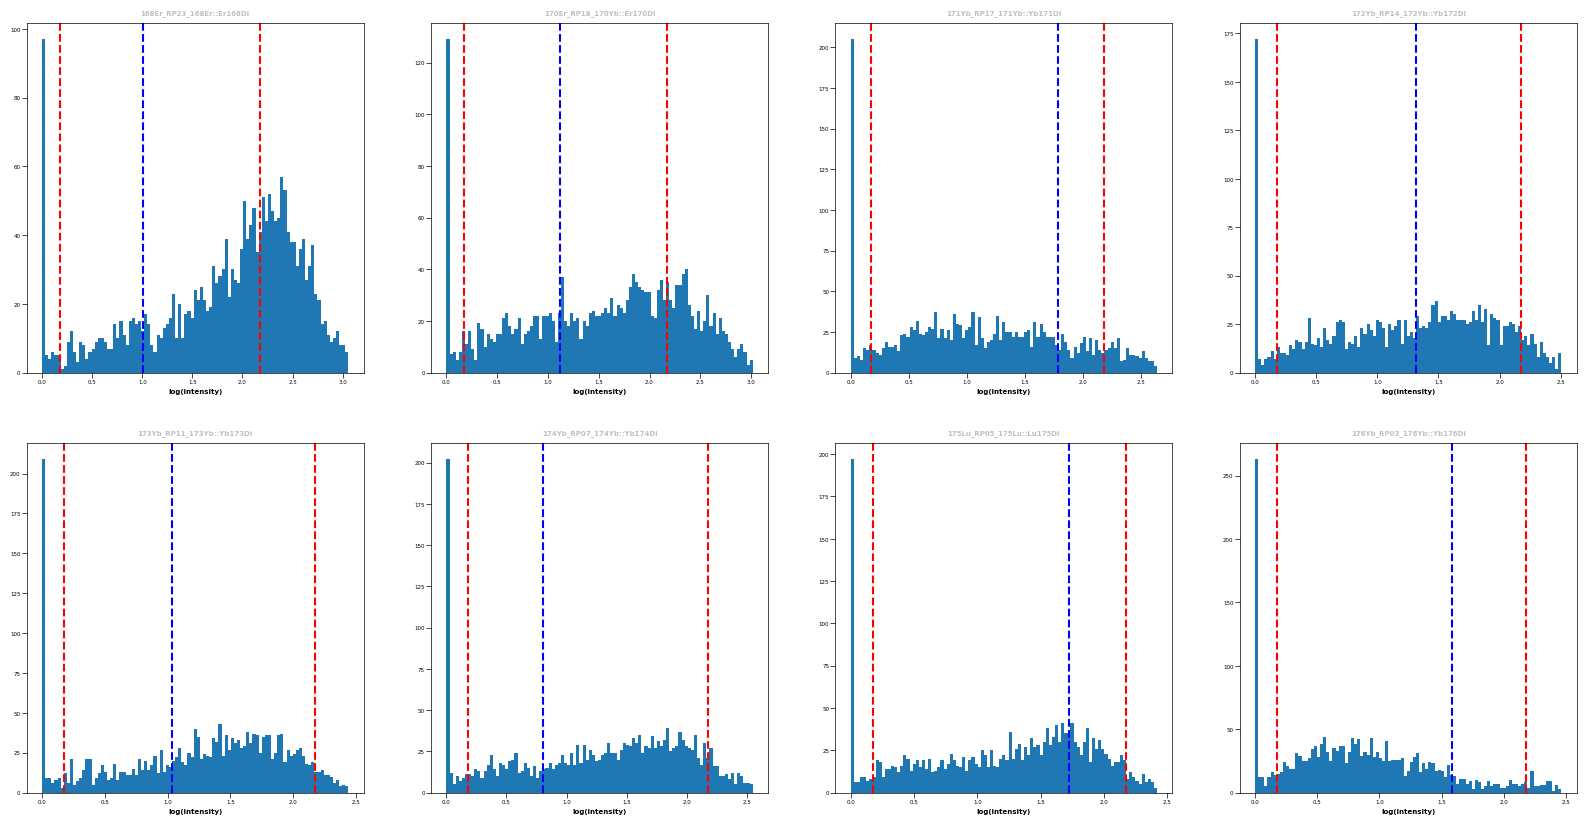

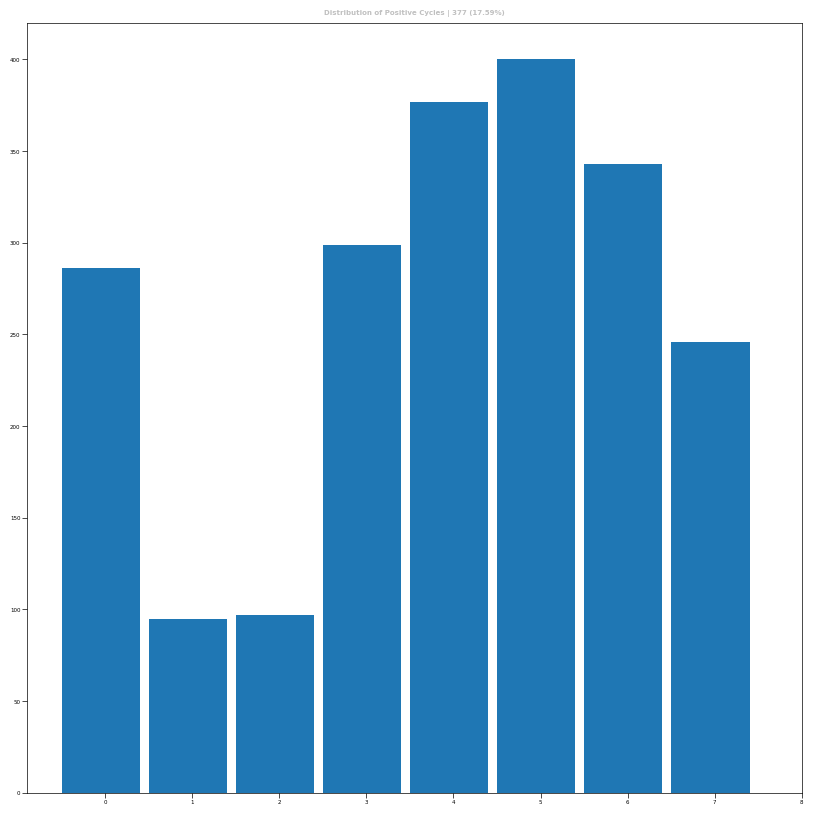

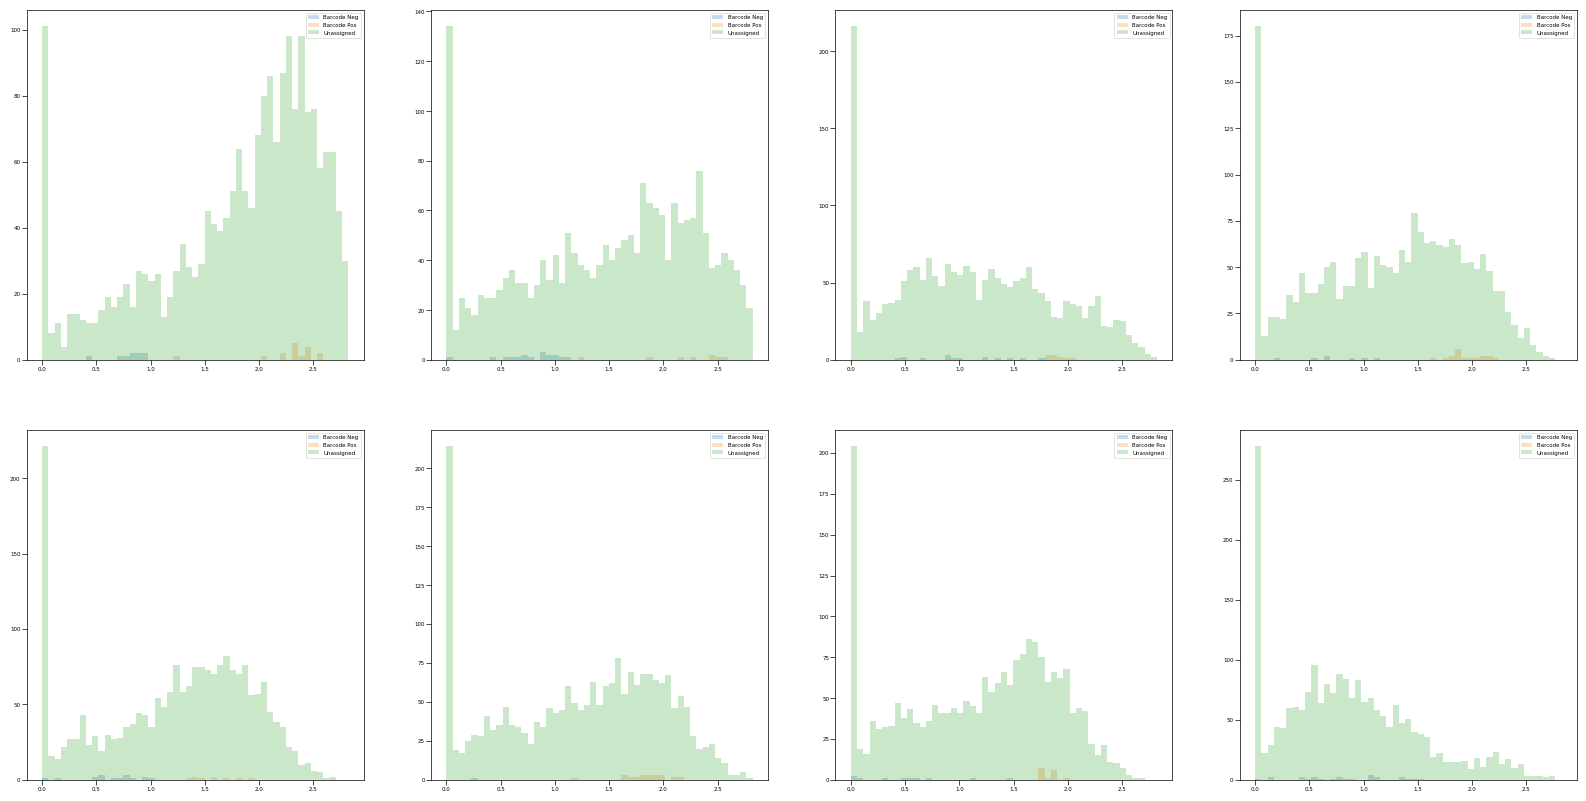

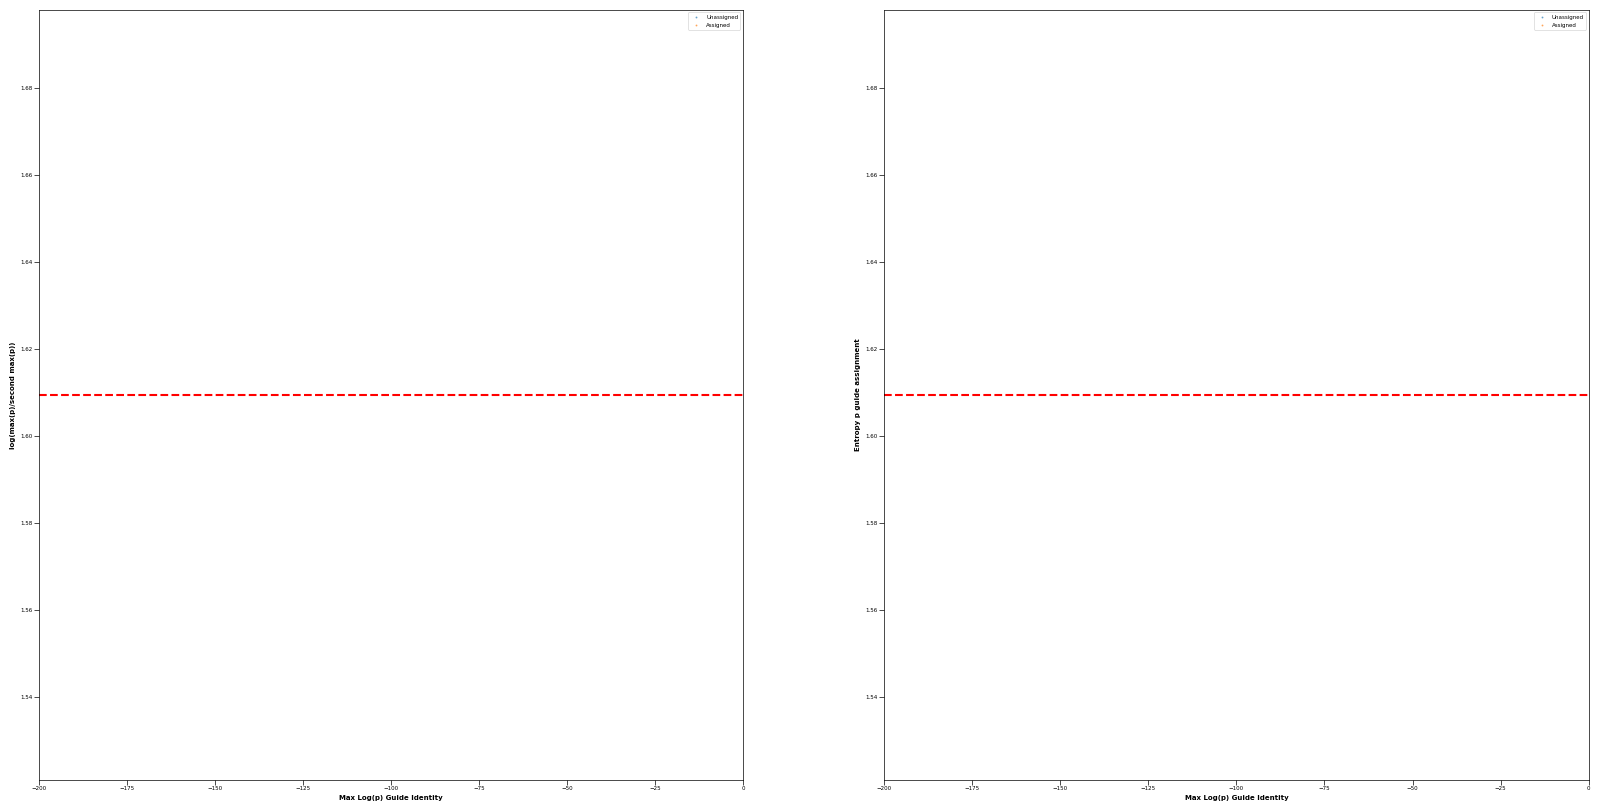

In [193]:
# Read in spots
# spot_intensities = pd.read_csv('/mnt/disks/external/juj2102/cyTOFcmap/A2_spotsDFintensities_max.csv')
# spot_intensities.drop(columns = ['Unnamed: 0'], inplace = True)
spot_intensities = pd.read_csv('/mnt/disks/external/juj2102/cyTOFcmap/flowdata/Cells_2_10nM_Reconjugated_Oligos_Gated.csv')
spot_intensities = spot_intensities.filter(regex=r'RP')
spot_intensities
print(spot_intensities.shape)

# ID all spots with nan values in any cycle
nan_rows = []
for col in spot_intensities:
    nan_rows.append(np.where(~np.isfinite(spot_intensities[col])))

# Remove the nan spots
nan_rows = np.unique(nan_rows)
spot_intensities.loc[nan_rows, :]=0

debarcoder = barcodeReadout(spot_intensities, cb, low_param = 1.5, upper_param = 150, log = True)
spot_intensities = debarcoder.get_intensity_table()

# The black box optimizer I'm using doesn't allow me to pass additional paramters, 
# so I need to redefine the score function with the table in scope
# This is really not good, but for now it works okay
def score_fun(threshs):
    binary_table = np.zeros(spot_intensities.shape, dtype=bool)
    for i in range(spot_intensities.shape[1]):
        binary_table[:,i] = spot_intensities[:,i]>threshs[i]

    num_pos = np.sum(binary_table, axis = 1)
    min_objective = np.abs(np.average(num_pos)-4)
    #min_objective = np.sum(num_pos!=4)/len(num_pos)
    return min_objective


debarcoder.overlap_optimization(batch_size = 30)
debarcoder.probabilistic_assignment(ratio = 5)
debarcoder.plot_results()

ids, prob_assign = debarcoder.get_assignment(overlap_assign = False)
ids, olap_assign = debarcoder.get_assignment(overlap_assign = True)

filehandler = open(opdir+ runName + '_prob_and_overlap_assign' '.pkl', 'wb')
pkl.dump((prob_assign, olap_assign), filehandler)
filehandler.close()

In [194]:
spot_intensities = pd.read_csv('/mnt/disks/external/juj2102/cyTOFcmap/flowdata/Cells_2_10nM_Reconjugated_Oligos_Gated.csv')
spot_intensities = spot_intensities.filter(regex=r'RP')
spot_intensities['olap_assign'] = olap_assign.tolist()
spot_intensities['GFP001'] = np.where(spot_intensities['olap_assign'] == 'GFP001',1,0) 
colors = np.where(spot_intensities["GFP001"]==1,'r','k')
size = np.where(spot_intensities["GFP001"]==1, 2, 0.5)
values = spot_intensities.iloc[:,0:8]
values = values.to_numpy()
cols = list(spot_intensities)
cols = cols[0:8]
cols

['168Er_RP23_168Er::Er168Di',
 '170Er_RP18_170Yb::Er170Di',
 '171Yb_RP17_171Yb::Yb171Di',
 '172Yb_RP14_172Yb::Yb172Di',
 '173Yb_RP11_173Yb::Yb173Di',
 '174Yb_RP07_174Yb::Yb174Di',
 '175Lu_RP05_175Lu::Lu175Di',
 '176Yb_RP03_176Yb::Yb176Di']

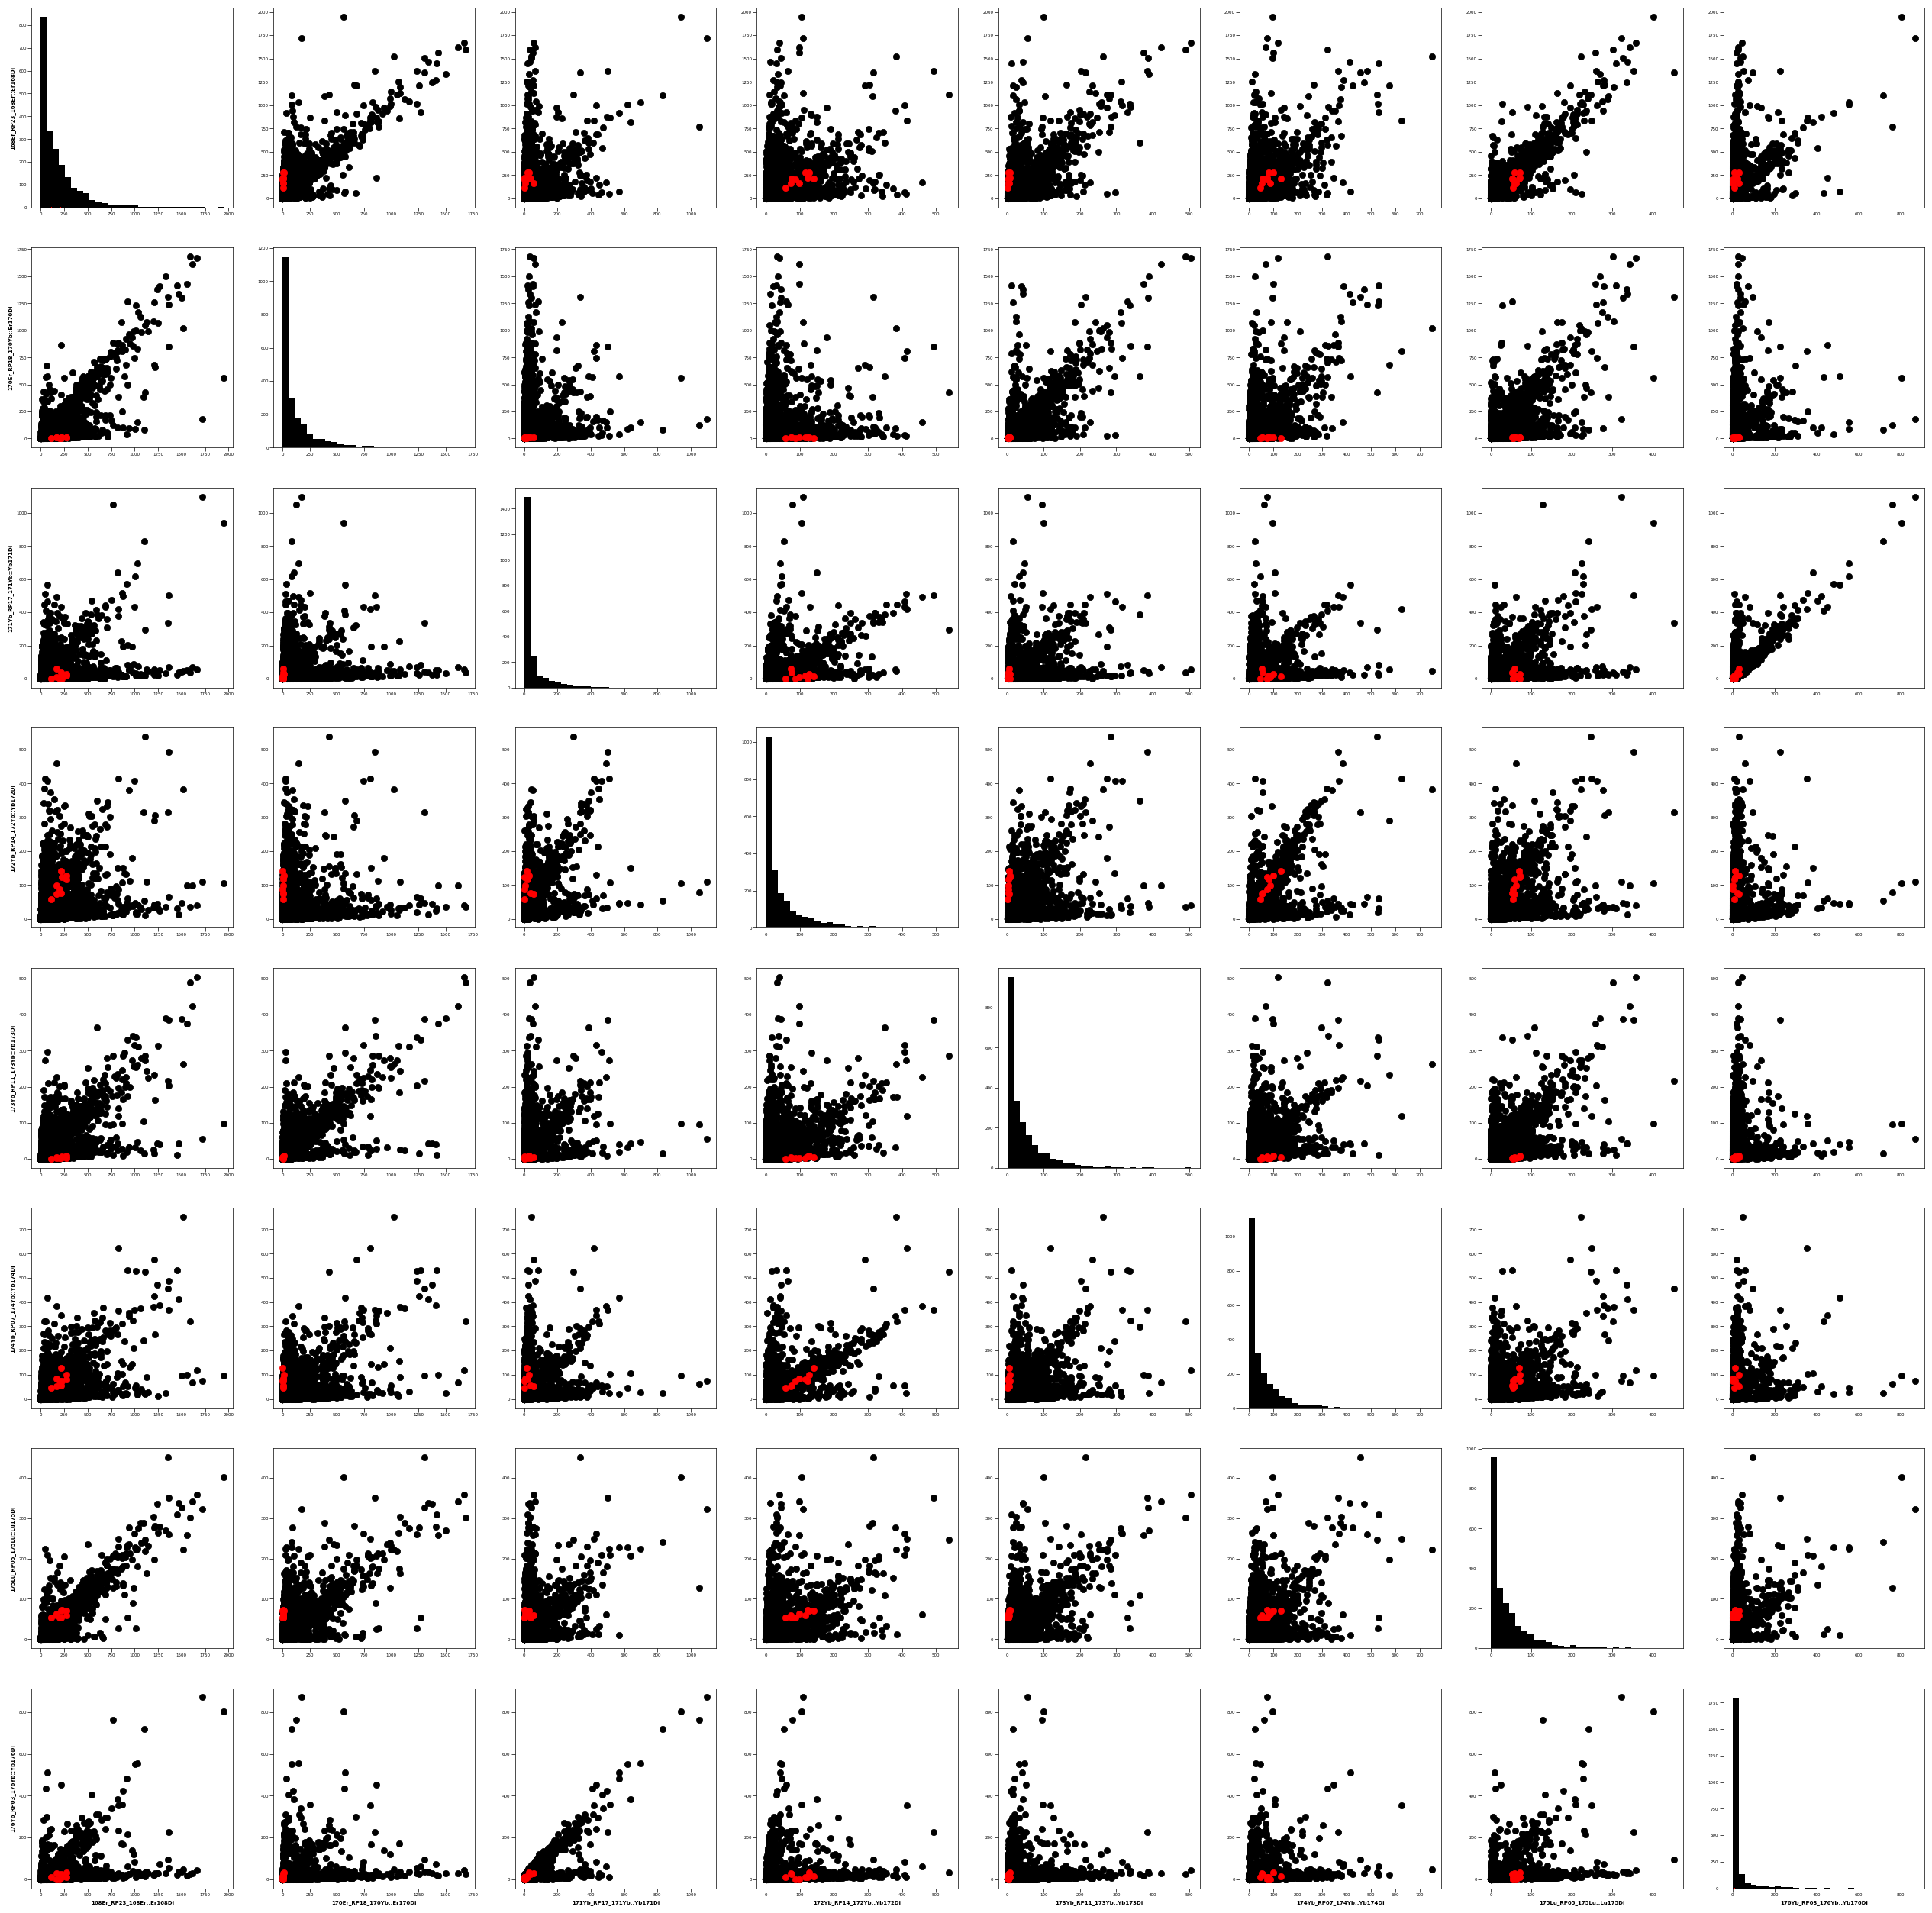

<Figure size 640x480 with 0 Axes>

In [195]:
myplotGrid(values, spot_intensities["GFP001"], cols, colormap={0: "black", 1: "red"})

In [ ]:
ax1 = ax[0,0]
spot_intensities.plot.scatter(x="RP07",y="RP05",c=colors, ax = ax1, s = 0.5)
ax1.set_xlabel("RP07")
ax1.set_ylabel("RP05")
ax1.set_title('RP07 v RP05', style="italic", pad=2, linespacing=1.5)

# # # add lines
# # plt.axhline(y=1, c='#C0C0C0', linestyle='dashed')
# # plt.axhline(y=0, c='#C0C0C0', linestyle='dashed')

# # axis
# ax1.tick_params(axis='both', which='major', length=2)
# ax1.grid(False)
# ax1.spines['bottom'].set_color('black')
# ax1.spines['top'].set_color('white')
# ax1.spines['right'].set_color('white')
# ax1.spines['left'].set_color('black')
# ax1.xaxis.labelpad = 2
# ax1.yaxis.labelpad = 2
    
# #legend
# ax1.legend(loc=(0.28, 0.2),labels=['Twinkle - Dendrite', "Twinkle + Dendrite", "Twinkle - Axon",'Twinkle + Axon']) # set location using loc=(x,y) as proportion on the plot

# # pos = ["Positive Axon", "Positive Dendrite"]
# # neg = ["Negative Axon", "Negative Dendrite"]

# # p value annotation
# text = "text"
# ax1.text(0.8, 0.3, text, transform=ax1.transAxes, ha='right', fontsize=5)
# #add_panel_label(ax2, 'B')

# savedir=opdir
# plt.savefig(savedir+"mrubyvprobefluorescence-mean.pdf", format="pdf", bbox_inches="tight")